# методы обучения на многообразиях

In [11]:
!pip install numpy pandas matplotlib seaborn scikit-learn plotly ipywidgets Pillow mcolors

ERROR: Could not find a version that satisfies the requirement mcolors (from versions: none)
ERROR: No matching distribution found for mcolors


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import LocallyLinearEmbedding, MDS, Isomap
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.datasets import load_digits
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

In [5]:
df = pd.read_csv('./Job_Placement_Data_Enhanced.csv')

df.info()
df.describe()

from sklearn.preprocessing import OneHotEncoder

object_cols = [t for t in df.select_dtypes(include='object').columns.to_list() if t != 'status']
for col in object_cols:
    cats = np.unique(df[col].values)
    l_enc = OneHotEncoder().fit(cats.reshape(1, -1))
    encoded_names = l_enc.get_feature_names_out(cats)
    for cat, name in zip(cats, encoded_names):
        df[name] = (df[col] == cat).astype(int)


placed = df[df['status'] == 'Placed'].copy()
not_placed = df[df['status'] == 'Not Placed'].copy()
delta = len(placed) - len(not_placed)
df = pd.concat([df, not_placed.sample(n=delta, replace=True)])
target_classes = df.select_dtypes(include='number').columns.to_list()
feature_cols = [col for col in df.columns if col not in ['status', 'status_enc', *object_cols]]

le = LabelEncoder()
df['status_enc'] = le.fit_transform(df['status'])
X_raw = df[feature_cols]
y = df['status_enc']
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X_sub = X
y_sub = y

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 215 non-null    object 
 1   ssc_percentage         215 non-null    float64
 2   ssc_board              215 non-null    object 
 3   hsc_percentage         215 non-null    float64
 4   hsc_board              215 non-null    object 
 5   hsc_subject            215 non-null    object 
 6   degree_percentage      215 non-null    float64
 7   undergrad_degree       215 non-null    object 
 8   work_experience        215 non-null    object 
 9   emp_test_percentage    215 non-null    float64
 10  specialisation         215 non-null    object 
 11  mba_percent            215 non-null    float64
 12  status                 215 non-null    object 
 13  years_experience       215 non-null    int64  
 14  skills_match_percent   215 non-null    int64  
 15  num_ce

датасет содержит 6 признаков, из которых 3 категориальные закодированы числами. После стандартизации все признаки на едином масштабе. сделал подвыборку до 2000 образцов ускоряет вычисления без потери репрезентативности

## 1: Визуализация связей

In [7]:
from PIL import Image, ImageDraw, ImageFont
from sklearn.neighbors import NearestNeighbors

def make_hello(N=1000, rseed=42):
    img = Image.new('L', (300, 100), color=0)
    draw = ImageDraw.Draw(img)
    draw.text((10, 10), 'HELLO', fill=255)
    pixels = np.array(img)
    ys, xs = np.where(pixels > 128)
    rng = np.random.RandomState(rseed)
    idx = rng.choice(len(xs), N, replace=True)
    X = np.column_stack([xs[idx], -ys[idx]]).astype(float)
    X += rng.normal(0, 0.5, X.shape)
    X -= X.mean(0)
    X /= X.std()
    return X

def make_hello_s_curve(X):
    t = (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min()) * np.pi
    s = X[:, 1]
    x3 = np.sin(t)
    y3 = s
    z3 = np.sign(np.cos(t)) * (np.cos(t) - 1)
    return np.column_stack([x3, y3, z3])

X2d = make_hello(N=1000, rseed=42)
X3d = make_hello_s_curve(X2d)
print('2D shape:', X2d.shape, '3D shape:', X3d.shape)

2D shape: (1000, 2) 3D shape: (1000, 3)


In [8]:
n_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(X3d)
distances, indices = nbrs.kneighbors(X3d)

#строим линии для LLE(локальные соседи)
lle_lines_x, lle_lines_y, lle_lines_z = [], [], []
for i in range(len(X3d)):
    for j in indices[i][1:]:
        lle_lines_x += [X3d[i,0], X3d[j,0], None]
        lle_lines_y += [X3d[i,1], X3d[j,1], None]
        lle_lines_z += [X3d[i,2], X3d[j,2], None]

#Строим линии для MDS
rng = np.random.RandomState(0)
pairs = rng.choice(len(X3d), size=(300, 2), replace=True)
mds_lines_x, mds_lines_y, mds_lines_z = [], [], []
for i, j in pairs:
    mds_lines_x += [X3d[i,0], X3d[j,0], None]
    mds_lines_y += [X3d[i,1], X3d[j,1], None]
    mds_lines_z += [X3d[i,2], X3d[j,2], None]

fig = make_subplots(rows=1, cols=2,
    specs=[[{'type':'scatter3d'}, {'type':'scatter3d'}]],
    subplot_titles=['LLE: локальные связи (n_neighbors=5)', 'MDS: глобальные (попарные) расстояния'])

colors = X3d[:, 0]
scatter_kwargs = dict(mode='markers',
    marker=dict(size=2, color=colors, colorscale='Viridis', opacity=0.7))

fig.add_trace(go.Scatter3d(x=X3d[:,0], y=X3d[:,1], z=X3d[:,2], name='points', **scatter_kwargs), row=1, col=1)
fig.add_trace(go.Scatter3d(x=lle_lines_x, y=lle_lines_y, z=lle_lines_z,
    mode='lines', line=dict(color='red', width=1), name='LLE edges', opacity=0.3), row=1, col=1)

fig.add_trace(go.Scatter3d(x=X3d[:,0], y=X3d[:,1], z=X3d[:,2], name='points', **scatter_kwargs), row=1, col=2)
fig.add_trace(go.Scatter3d(x=mds_lines_x, y=mds_lines_y, z=mds_lines_z,
    mode='lines', line=dict(color='blue', width=1), name='MDS edges', opacity=0.2), row=1, col=2)

fig.update_layout(height=500, title_text='S-кривая HELLO: структура связей LLE vs MDS', showlegend=False)
fig.show()

LLE соединяет только ближайших соседей (локальные связи образуют цепочки вдоль буквы), MDS строит хаотичные длинные дуги между далёкими точками

##2: Функции преобразования


In [9]:
def manifold_plane(X):
    return np.column_stack([X[:, 0], X[:, 1], np.zeros(len(X))])

def manifold_s_curve(X):
    t = X[:, 0] * np.pi
    s = X[:, 1]
    return np.column_stack([np.sin(t), s, np.sign(np.cos(t)) * (np.cos(t) - 1)])

def manifold_mobius(X):
    t = X[:, 0] * np.pi
    s = X[:, 1] * 0.5
    x = (1 + s * np.cos(t)) * np.cos(2 * t)
    y = (1 + s * np.cos(t)) * np.sin(2 * t)
    z = s * np.sin(t)
    return np.column_stack([x, y, z])

def manifold_cylinder(X):
    theta = X[:, 0] * np.pi
    h = X[:, 1]
    return np.column_stack([np.cos(theta), h, np.sin(theta)])

def manifold_helicoid(X):
    t = X[:, 0] * 2 * np.pi
    r = X[:, 1]
    return np.column_stack([r * np.cos(t), r * np.sin(t), t])

def manifold_cone(X):
    r = np.abs(X[:, 0])
    theta = X[:, 1] * np.pi
    return np.column_stack([r * np.cos(theta), r * np.sin(theta), r])

def manifold_roll(X):
    t = 1.5 * np.pi * (1 + 2 * (X[:, 0] + 1) / 2)
    h = X[:, 1]
    return np.column_stack([t * np.cos(t), h, t * np.sin(t)])

def manifold_custom(X):
    r = X[:, 0]
    theta = X[:, 1] * np.pi
    return np.column_stack([r * np.cos(theta), r * np.sin(theta), r ** 2])

MANIFOLDS = {
    'plane': manifold_plane,
    's_curve': manifold_s_curve,
    'mobius': manifold_mobius,
    'cylinder': manifold_cylinder,
    'helicoid': manifold_helicoid,
    'cone': manifold_cone,
    'roll': manifold_roll,
    'custom (paraboloid)': manifold_custom,
}

#демонстрация Swiss roll
rng = np.random.RandomState(42)
X2d_demo = rng.uniform(-1, 1, (500, 2))
X_roll = manifold_roll(X2d_demo)
print('Swiss roll shape:', X_roll.shape)

Swiss roll shape: (500, 3)


разные типы поверхностей требуют разных методов. Плоскость разворачивается любым методом без ошибок. Лента Мёбиуса имеет топологическое скручивание и не может быть корректно развёрнута в 2D без разрезов

Вспомогательные функции

In [10]:
class MplColorHelper:
    def __init__(self, cmap_name, start_val, stop_val):
        self.cmap_name = cmap_name
        self.cmap = plt.get_cmap(cmap_name)
        self.norm = mcolors.Normalize(vmin=start_val, vmax=stop_val)
        self.scalarMap = cm.ScalarMappable(norm=self.norm, cmap=self.cmap)
    def get_rgb(self, val):
        return self.scalarMap.to_rgba(val)

def linear_embedding(datapoints, neighbors):
    lle = LocallyLinearEmbedding(n_neighbors=neighbors, n_components=2, method='standard', random_state=42)
    return lle.fit_transform(datapoints)

def multidim_scaling(datapoints, neighbors):
    mds = MDS(n_components=2, max_iter=300, n_init=1, random_state=42, normalized_stress='auto')
    return mds.fit_transform(datapoints)

def isomap(datapoints, neighbors):
    iso = Isomap(n_neighbors=neighbors, n_components=2)
    return iso.fit_transform(datapoints)

def unwind_manifold(X3d, method, n_neighbors):
    if method == 'LLE':
        return linear_embedding(X3d, n_neighbors)
    elif method == 'MDS':
        return multidim_scaling(X3d, n_neighbors)
    else:
        return isomap(X3d, n_neighbors)


In [11]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import ipywidgets as widgets

class ManifoldExplorerApp:
    def __init__(self):
        self.rng = np.random.RandomState(42)
        self.X2d = self.rng.uniform(-1, 1, (400, 2))
        self.grid_size = 20
        gx = np.linspace(-1, 1, self.grid_size)
        gy = np.linspace(-1, 1, self.grid_size)
        gx, gy = np.meshgrid(gx, gy)
        self.grid2d = np.column_stack([gx.ravel(), gy.ravel()])
        self.color_helper = MplColorHelper('viridis', -1, 1)
        self.colors = self.X2d[:, 0]
        self._build_widgets()

    def _build_widgets(self):
        self.manifold_dd = widgets.Dropdown(
            options=list(MANIFOLDS.keys()), value='roll', description='Manifold:')
        self.method_dd = widgets.Dropdown(
            options=['LLE', 'MDS', 'Isomap'], value='Isomap', description='Method:')
        self.neighbors_sl = widgets.IntSlider(
            value=10, min=3, max=30, step=1, description='Neighbors:')
        self.unfold_btn = widgets.Button(
            description='Unfold', button_style='primary')
        self.progress = widgets.IntProgress(
            value=0, min=0, max=10, description='', layout=widgets.Layout(width='300px'))
        self.out = widgets.Output()
        self.unfold_btn.on_click(self._on_unfold)

    def _get_3d(self):
        fn = MANIFOLDS[self.manifold_dd.value]
        return fn(self.X2d), fn(self.grid2d)

    def _on_unfold(self, b):
        self.out.clear_output()
        with self.out:
            self.progress.value = 2
            X3d, grid3d = self._get_3d()
            self.progress.value = 5
            X2d_result = unwind_manifold(X3d, self.method_dd.value, self.neighbors_sl.value)
            self.progress.value = 9
            self._plot(X3d, grid3d, X2d_result)
            self.progress.value = 10

    def _plot(self, X3d, grid3d, X2d_result):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax3 = fig.add_subplot(121, projection='3d')
        ax3.scatter(X3d[:,0], X3d[:,1], X3d[:,2],
            c=self.colors, cmap='viridis', s=10, alpha=0.7)
        g = self.grid2d
        gx = grid3d[:, 0].reshape(self.grid_size, self.grid_size)
        gy = grid3d[:, 1].reshape(self.grid_size, self.grid_size)
        gz = grid3d[:, 2].reshape(self.grid_size, self.grid_size)
        ax3.plot_wireframe(gx, gy, gz, color='gray', alpha=0.2, linewidth=0.5)
        ax3.set_title(f'3D: {self.manifold_dd.value}')
        ax2 = axes[1]
        ax2.scatter(X2d_result[:,0], X2d_result[:,1],
            c=self.colors, cmap='viridis', s=10, alpha=0.7)
        ax2.set_title(f'2D ({self.method_dd.value}, k={self.neighbors_sl.value})')
        ax2.axis('equal')
        plt.tight_layout()
        plt.show()

    def display(self):
        controls = widgets.HBox([self.manifold_dd, self.method_dd, self.neighbors_sl, self.unfold_btn])
        display(widgets.VBox([controls, self.progress, self.out]))

app = ManifoldExplorerApp()
app.display()

для swiss roll Isomap и LLE успешно разворачиваем поверхность, тогда как MDS искажает её из-за ориентации на евклидовы, а не геодезические расстояния

## 4: сравнение методов DR

In [12]:
print('PCA')
X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_sub)
print('LLE')
X_lle2 = LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=42).fit_transform(X_sub)
print('Isomap...')
X_iso2 = Isomap(n_neighbors=10, n_components=2).fit_transform(X_sub)
print('MDS')
X_mds2 = MDS(n_components=2, max_iter=300, n_init=1, random_state=42, normalized_stress='auto').fit_transform(X_sub)
print('Готово.')

PCA
LLE
Isomap...
MDS
Готово.


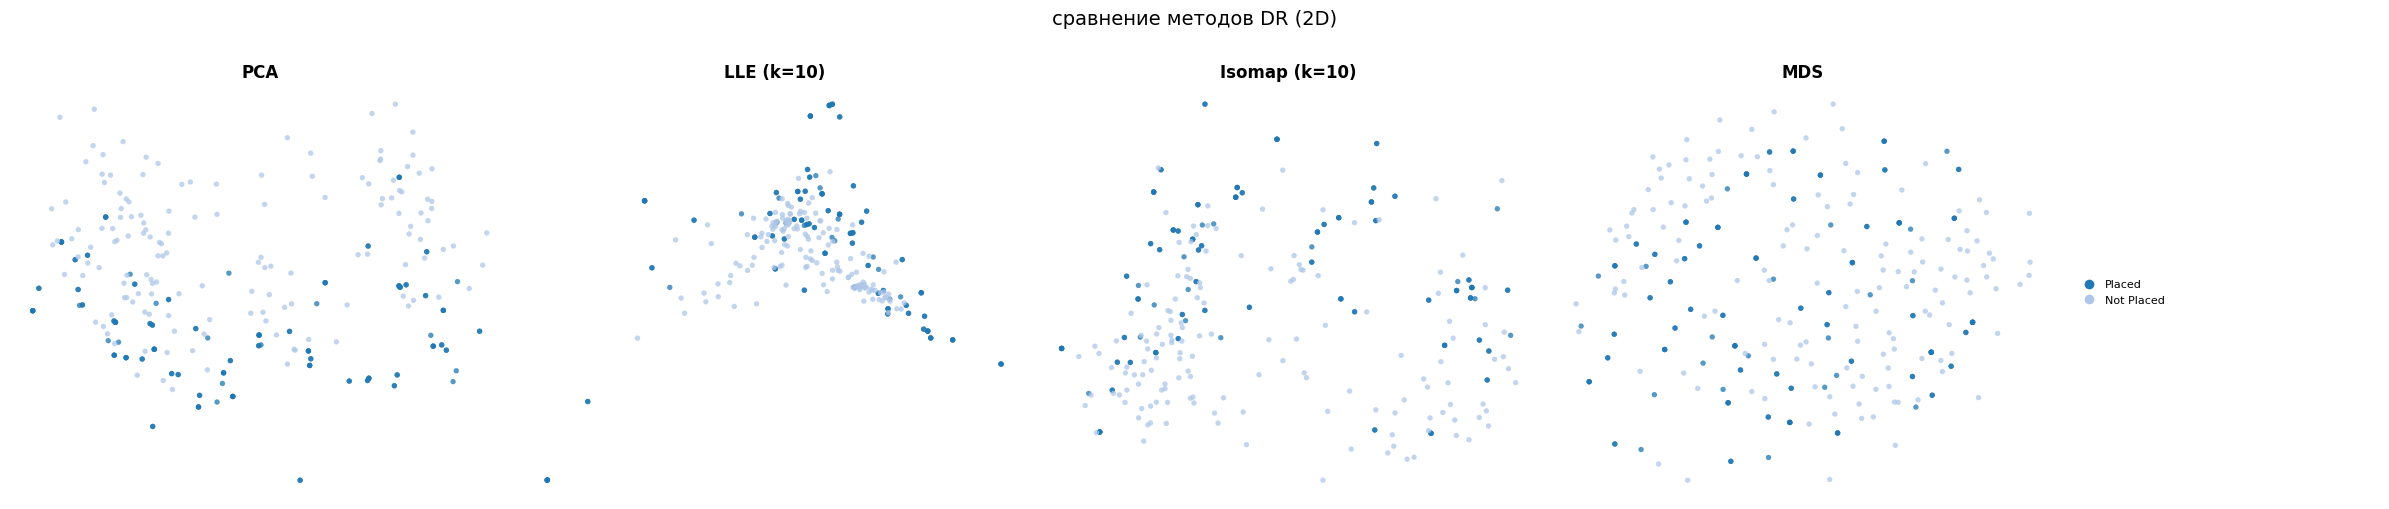

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Для 21+ класса комбинируем tab20 + tab20b → 40 уникальных цветов
colors_tab20  = [plt.cm.tab20(i)  for i in np.linspace(0, 1, 20, endpoint=False)]
colors_tab20b = [plt.cm.tab20b(i) for i in np.linspace(0, 1, 20, endpoint=False)]
all_colors = colors_tab20 + colors_tab20b  # 40 цветов

unique_labels = list(range(2))
labels_names = {0: 'Placed', 1: 'Not Placed'}

n_classes = len(unique_labels)
clrs = all_colors[:n_classes]  # берём ровно столько, сколько нужно

methods = {
    'PCA': X_pca2,
    'LLE (k=10)': X_lle2,
    'Isomap (k=10)': X_iso2,
    'MDS': X_mds2,
}

fig, axes = plt.subplots(1, 5, figsize=(24, 5),
                         gridspec_kw={'width_ratios': [4, 4, 4, 4, 2.5]})

for ax, (name, X2) in zip(axes[:4], methods.items()):
    for i, lbl in enumerate(unique_labels):
        mask = y_sub == lbl
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   s=15, alpha=0.75,
                   color=clrs[i],
                   edgecolors='none')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axis('off')

# Легенда на отдельной оси
legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=clrs[i],
           markersize=8, label=labels_names[lbl])
    for i, lbl in enumerate(unique_labels)
]
axes[4].legend(handles=legend_handles,
               loc='center left', fontsize=8,
               frameon=False, ncol=1,
               handletextpad=0.4, labelspacing=0.5)
axes[4].axis('off')

plt.suptitle('сравнение методов DR (2D)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

на 2D проекциях все четыре метода частично разделяют классы. PCA и Isomap дают более компактные кластеры, LLE чувствителен к выбору числа соседей. MDS сохраняет глобальные расстояния но медленнее остальных

 ## 5: Классификация KNN после понижения размерности

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.5, shuffle=False)

# Обучаем преобразования только на train, применяем к test
pca_tr = PCA(n_components=2, random_state=42).fit(X_tr)
lle_tr = LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=42).fit(X_tr)
iso_tr = Isomap(n_neighbors=10, n_components=2).fit(X_tr)

models = {
    'KNN (raw)': (X_tr, X_te),
    'PCA + KNN': (pca_tr.transform(X_tr), pca_tr.transform(X_te)),
    'LLE + KNN': (lle_tr.transform(X_tr), lle_tr.transform(X_te)),
    'Isomap + KNN': (iso_tr.transform(X_tr), iso_tr.transform(X_te)),
}

results = {}
for name, (Xtr, Xte) in models.items():
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(Xtr, y_tr)
    y_pred = knn.predict(Xte)
    acc = accuracy_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred, labels=unique_labels)
    results[name] = {'acc': acc, 'cm': cm}
    print(f'{name}: accuracy = {acc:.3f}')

KNN (raw): accuracy = 0.527
PCA + KNN: accuracy = 0.608
LLE + KNN: accuracy = 0.405
Isomap + KNN: accuracy = 0.527


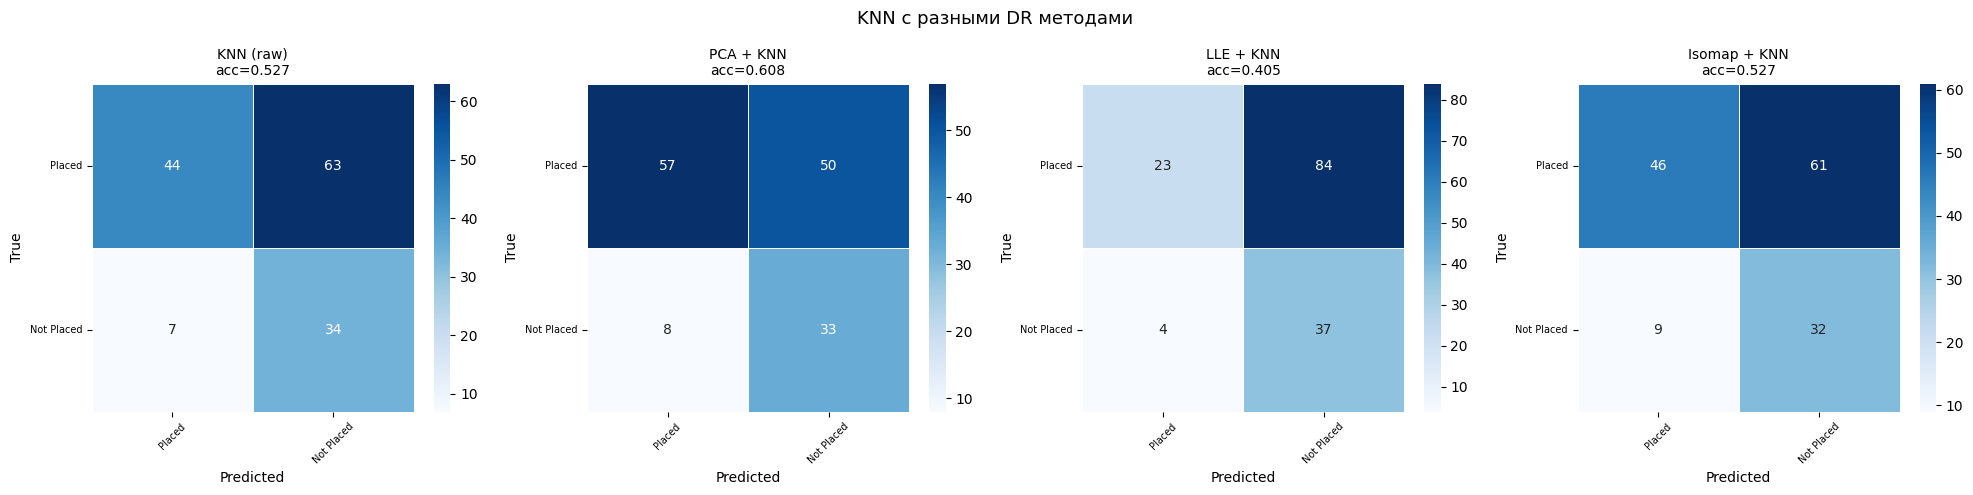

In [19]:
class_names = [labels_names[i] for i in unique_labels]
n_methods = len(results)
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', ax=ax,
        xticklabels=class_names, yticklabels=class_names,
        cmap='Blues', linewidths=0.5)
    ax.set_title(f'{name}\nacc={res["acc"]:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('KNN с разными DR методами', fontsize=13)
plt.tight_layout()
plt.show()

 Методы DR снижают шум и выделяют структуру данных, что помогает KNN находить более чистые границы классов. Isomap и LLE, как правило, дают прирост точности по сравнению с KNN на сырых данных если в данных есть нелинейная структура